<a href="https://colab.research.google.com/github/Tejaswimadastu/Deep_Learning/blob/main/News_Summary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ==========================================
# STEP 1: Download Dataset
# ==========================================

import kagglehub

path = kagglehub.dataset_download("sunnysai12345/news-summary")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'news-summary' dataset.
Path to dataset files: /kaggle/input/news-summary


In [3]:


import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

In [4]:


print(os.listdir(path))

['news_summary_more.csv', 'news_summary.csv']


In [5]:


df = pd.read_csv(
    os.path.join(path, "news_summary.csv"),
    encoding="latin-1"
)

df.head()

,author,date,headlines,read_more,text,ctext
0,Chhavi Tyagi,"03 Aug 2017,Thursday",Daman & Diu revokes mandatory Rakshabandhan in...,http://www.hindustantimes.com/india-news/raksh...,The Administration of Union Territory Daman an...,The Daman and Diu administration on Wednesday ...
1,Daisy Mowke,"03 Aug 2017,Thursday",Malaika slams user who trolled her for 'divorc...,http://www.hindustantimes.com/bollywood/malaik...,Malaika Arora slammed an Instagram user who tr...,"From her special numbers to TV?appearances, Bo..."
2,Arshiya Chopra,"03 Aug 2017,Thursday",'Virgin' now corrected to 'Unmarried' in IGIMS...,http://www.hindustantimes.com/patna/bihar-igim...,The Indira Gandhi Institute of Medical Science...,The Indira Gandhi Institute of Medical Science...
3,Sumedha Sehra,"03 Aug 2017,Thursday",Aaj aapne pakad liya: LeT man Dujana before be...,http://indiatoday.intoday.in/story/abu-dujana-...,Lashkar-e-Taiba's Kashmir commander Abu Dujana...,Lashkar-e-Taiba's Kashmir commander Abu Dujana...
4,Aarushi Maheshwari,"03 Aug 2017,Thursday",Hotel staff to get training to spot signs of s...,http://indiatoday.intoday.in/story/sex-traffic...,Hotels in Maharashtra will train their staff t...,Hotels in Mumbai and other Indian cities are t...


In [6]:


print("Dataset Shape:", df.shape)

Dataset Shape: (4514, 6)


In [7]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4514 entries, 0 to 4513
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   author     4514 non-null   object
 1   date       4514 non-null   object
 2   headlines  4514 non-null   object
 3   read_more  4514 non-null   object
 4   text       4514 non-null   object
 5   ctext      4396 non-null   object
dtypes: object(6)
memory usage: 211.7+ KB


In [8]:

print(df.columns)

Index(['author', 'date', 'headlines', 'read_more', 'text', 'ctext'], dtype='object')


In [9]:


print("Total Records:", len(df))

Total Records: 4514


In [10]:
print(df.isnull().sum())

author         0
date           0
headlines      0
read_more      0
text           0
ctext        118
dtype: int64


In [11]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [12]:
df["article_length"] = df["text"].astype(str).apply(
    lambda x: len(x.split())
)

df["article_length"].head()

,article_length
0,60
1,60
2,60
3,60
4,60


In [13]:
df["summary_length"] = df["headlines"].astype(str).apply(
    lambda x: len(x.split())
)

df["summary_length"].head()

,summary_length
0,9
1,10
2,8
3,10
4,11


In [14]:
avg_article_length = df["article_length"].mean()
avg_summary_length = df["summary_length"].mean()

print("Average Article Length :", round(avg_article_length,2))
print("Average Summary Length :", round(avg_summary_length,2))

Average Article Length : 58.29
Average Summary Length : 9.29


In [15]:
print("Article Statistics")
print("------------------")
print("Minimum:", df["article_length"].min())
print("Maximum:", df["article_length"].max())
print("Average:", round(df["article_length"].mean(),2))

print()

print("Summary Statistics")
print("------------------")
print("Minimum:", df["summary_length"].min())
print("Maximum:", df["summary_length"].max())
print("Average:", round(df["summary_length"].mean(),2))

Article Statistics
------------------
Minimum: 44
Maximum: 62
Average: 58.29

Summary Statistics
------------------
Minimum: 4
Maximum: 14
Average: 9.29


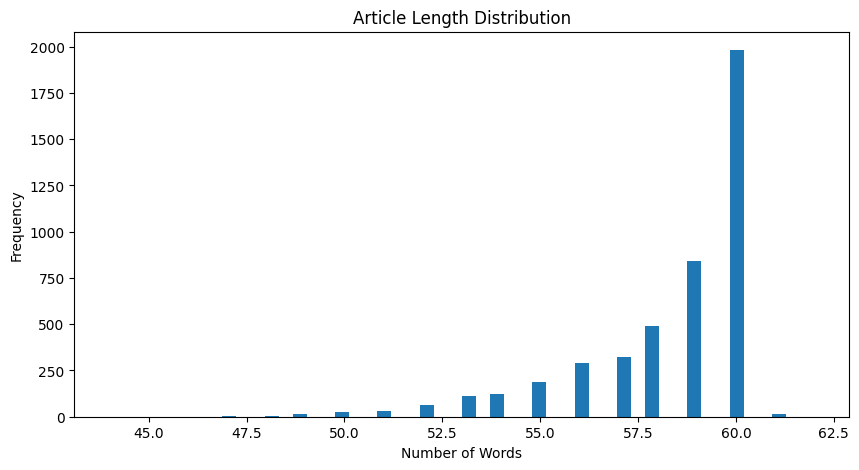

In [16]:
plt.figure(figsize=(10,5))

plt.hist(
    df["article_length"],
    bins=50
)

plt.title("Article Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

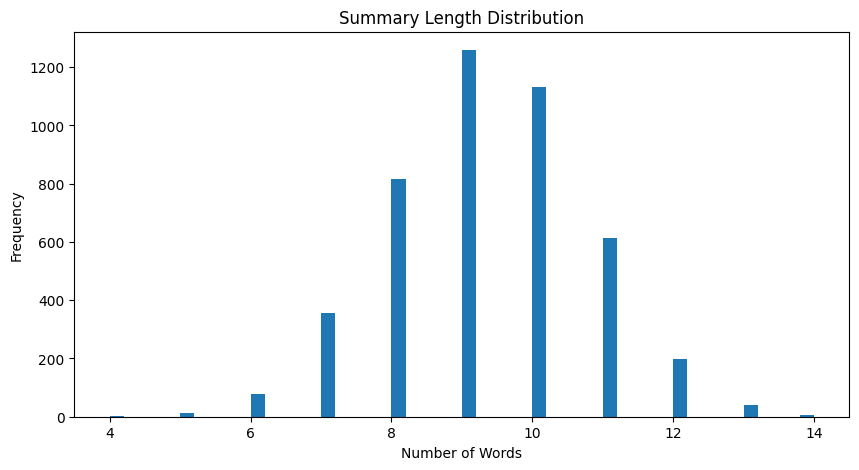

In [17]:
plt.figure(figsize=(10,5))

plt.hist(
    df["summary_length"],
    bins=50
)

plt.title("Summary Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

In [18]:
print("\n========== EDA REPORT ==========\n")

print("Number of Records      :", len(df))
print("Average Article Length :", round(avg_article_length,2))
print("Average Summary Length :", round(avg_summary_length,2))
print("Duplicate Rows         :", df.duplicated().sum())

print("\nMissing Values")
print(df.isnull().sum())


========== EDA REPORT ==========

Number of Records      : 4514
Average Article Length : 58.29
Average Summary Length : 9.29
Duplicate Rows         : 0

Missing Values
author              0
date                0
headlines           0
read_more           0
text                0
ctext             118
article_length      0
summary_length      0
dtype: int64


# Task2

In [19]:
import re
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [20]:
articles = df["text"].astype(str)
summaries = df["headlines"].astype(str)

In [21]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [22]:
articles = articles.apply(clean_text)
summaries = summaries.apply(clean_text)

print("Sample Article:")
print(articles.iloc[0])

print("\nSample Summary:")
print(summaries.iloc[0])

Sample Article:
the administration of union territory daman and diu has revoked its order that made it compulsory for women to tie rakhis to their male colleagues on the occasion of rakshabandhan on august the administration was forced to withdraw the decision within hours of issuing the circular after it received flak from employees and was slammed on social media

Sample Summary:
daman diu revokes mandatory rakshabandhan in offices order


In [23]:
summaries = summaries.apply(
    lambda x: "startseq " + x + " endseq"
)

In [24]:
input_tokenizer = Tokenizer()
input_tokenizer.fit_on_texts(articles)

encoder_sequences = input_tokenizer.texts_to_sequences(articles)

input_vocab_size = len(input_tokenizer.word_index) + 1

print("Input Vocabulary Size:", input_vocab_size)

Input Vocabulary Size: 20958


In [25]:
target_tokenizer = Tokenizer()
target_tokenizer.fit_on_texts(summaries)

decoder_sequences = target_tokenizer.texts_to_sequences(summaries)

target_vocab_size = len(target_tokenizer.word_index) + 1

print("Target Vocabulary Size:", target_vocab_size)

Target Vocabulary Size: 8913


In [26]:
max_article_len = max(
    len(seq) for seq in encoder_sequences
)

max_summary_len = max(
    len(seq) for seq in decoder_sequences
)

print("Maximum Article Length:", max_article_len)
print("Maximum Summary Length:", max_summary_len)

Maximum Article Length: 61
Maximum Summary Length: 16


In [27]:
encoder_input_data = pad_sequences(
    encoder_sequences,
    maxlen=max_article_len,
    padding='post'
)

In [28]:
decoder_input_data = pad_sequences(
    decoder_sequences,
    maxlen=max_summary_len,
    padding='post'
)

In [29]:
decoder_target_data = []

for seq in decoder_sequences:
    decoder_target_data.append(seq[1:])

decoder_target_data = pad_sequences(
    decoder_target_data,
    maxlen=max_summary_len,
    padding='post'
)

decoder_target_data = decoder_target_data.reshape(
    decoder_target_data.shape[0],
    decoder_target_data.shape[1],
    1
)

In [30]:
print("Encoder Input Shape :", encoder_input_data.shape)
print("Decoder Input Shape :", decoder_input_data.shape)
print("Decoder Target Shape:", decoder_target_data.shape)

Encoder Input Shape : (4514, 61)
Decoder Input Shape : (4514, 16)
Decoder Target Shape: (4514, 16, 1)


# Task3

In [31]:
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense
from tensorflow.keras.models import Model

latent_dim = 256
embedding_dim = 128

In [32]:
encoder_inputs = Input(shape=(max_article_len,))

In [33]:
enc_emb = Embedding(
    input_vocab_size,
    embedding_dim,
    mask_zero=True
)(encoder_inputs)

In [34]:
encoder_lstm = LSTM(
    latent_dim,
    return_state=True
)

encoder_outputs, state_h, state_c = encoder_lstm(enc_emb)

In [35]:
encoder_states = [state_h, state_c]

# Task4 -Build Decoder

In [36]:
decoder_inputs = Input(shape=(max_summary_len,))

In [37]:
dec_emb_layer = Embedding(
    target_vocab_size,
    embedding_dim,
    mask_zero=True
)

dec_emb = dec_emb_layer(decoder_inputs)

In [38]:
decoder_lstm = LSTM(
    latent_dim,
    return_sequences=True,
    return_state=True
)

decoder_outputs, _, _ = decoder_lstm(
    dec_emb,
    initial_state=encoder_states
)

In [39]:
decoder_dense = Dense(
    target_vocab_size,
    activation='softmax'
)

decoder_outputs = decoder_dense(decoder_outputs)

In [40]:
model = Model(
    [encoder_inputs, decoder_inputs],
    decoder_outputs
)

In [41]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [42]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 61)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 16)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 61, 128)   │  2,682,624 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 61)        │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 16, 128)   │  1,140,864 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 256),     │    394,240 │ embedding[0][0],  │
│                     │ (None, 256),      │            │ not_equal[0][0]   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, 16, 256), │    394,240 │ embedding_1[0][0… │
│                     │ (None, 256),      │            │ lstm[0][1],       │
│                     │ (None, 256)]      │            │ lstm[0][2]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16, 8913)  │  2,290,641 │ lstm_1[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,902,609 (26.33 MB)

 Trainable params: 6,902,609 (26.33 MB)

 Non-trainable params: 0 (0.00 B)

# Task 5 - Train seq2seq model

In [43]:
history = model.fit(
    [encoder_input_data, decoder_input_data],
    decoder_target_data,
    batch_size=64,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 11s 73ms/step - accuracy: 0.1377 - loss: 7.5242 - val_accuracy: 0.2016 - val_loss: 6.8976
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.2039 - loss: 6.5027 - val_accuracy: 0.2006 - val_loss: 6.7424
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - accuracy: 0.2063 - loss: 6.2897 - val_accuracy: 0.2026 - val_loss: 6.7313
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - accuracy: 0.2115 - loss: 6.1547 - val_accuracy: 0.2060 - val_loss: 6.7377
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - accuracy: 0.2153 - loss: 6.0233 - val_accuracy: 0.2057 - val_loss: 6.7742
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.2187 - loss: 5.9079 - val_accuracy: 0.2047 - val_loss: 6.8037
Epoch 7/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.2216 - loss: 5.8174 - val_accuracy: 0.2048 - val_loss: 6.8741
Epoch 8/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - accuracy: 0.2234 - loss: 5.7418 - val_accuracy: 0.2006 - 

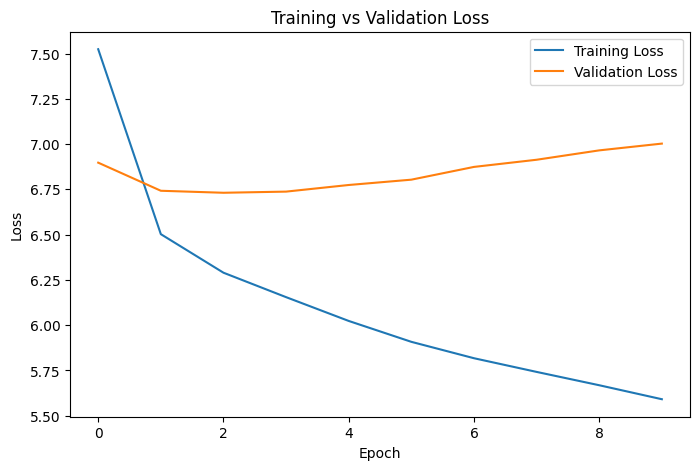

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Training Loss",
    "Validation Loss"
])

plt.show()

In [45]:
model.save("meeting_notes_summarizer.h5")

In [46]:
print("Final Training Accuracy :",
      round(history.history['accuracy'][-1] * 100, 2), "%")

print("Final Validation Accuracy :",
      round(history.history['val_accuracy'][-1] * 100, 2), "%")

Final Training Accuracy : 22.64 %
Final Validation Accuracy : 20.25 %
